# Sketch Algorithms: Approximate Counting at Scale
## From the General Paradigm to Count-Min Sketch

> *"All models are wrong, but some are useful." — George Box*

Imagine you're building monitoring for a major search engine, watching **billions of queries per second**. Your task: find which search terms are trending *right now*.

Storing every query in memory is impossible — you'd need terabytes of RAM. That's where **sketch algorithms** come in: probabilistic data structures that process streams in *tiny* memory while giving *provably accurate* approximate answers.

---

**What you'll learn:**
1. The streaming data problem and why exact counting fails at scale
2. Sketch algorithms as a general paradigm — the accuracy-memory bargain
3. **Count-Min Sketch (CMS)** — structure, operations, and intuition
4. A rigorous proof of CMS's $(\varepsilon, \delta)$-error guarantee
5. CMS in action: comparing exact counts vs. sketched estimates

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec
from collections import Counter
import random
import ipywidgets as widgets
from IPython.display import display

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#f8f8f8",
    "axes.grid":        True,
    "grid.color":       "white",
    "grid.linewidth":   1.2,
    "axes.spines.top":  False,
    "axes.spines.right": False,
    "font.family":      "sans-serif",
})

BLUE   = 'steelblue'
RED    = 'tomato'
GREEN  = 'mediumseagreen'
ORANGE = 'darkorange'
NAVY   = 'navy'

np.random.seed(42)
random.seed(42)
print("Libraries loaded.")

Libraries loaded.


---
## 1 · The Streaming Problem: When Data Moves Too Fast

### The Setting

A **data stream** is a sequence of items arriving one at a time:

$$\sigma = \langle a_1, a_2, a_3, \ldots, a_N \rangle, \quad a_i \in \mathcal{U} = \{1, 2, \ldots, u\}$$

Each $a_i$ might be a search query, a network packet's source IP, a word in a text corpus, or a product click. The key constraint: **we can only make one pass**, and we have **very limited memory**.

### The Frequency Vector

The central object of interest is the **frequency vector** $\mathbf{f} \in \mathbb{Z}^u$:

$$f_j = \left|\{i : a_i = j\}\right| \quad \text{(how many times item } j \text{ appeared)}$$

The total stream length is $N = \sum_j f_j$.

### Why Not Just Count Exactly?

| Universe | Unique Items $u$ | Memory for exact $\mathbf{f}$ |
|----------|-----------------|-------------------------------|
| English words | ~1 million | ~8 MB |
| IPv4 addresses | 4.3 billion | ~32 GB |
| IPv6 addresses | $3.4 \times 10^{38}$ | Astronomically impossible |
| URL parameter strings | Unbounded | Impossible |

> **Key insight:** For web-scale systems, we need memory that is *sublinear* in $u$ — ideally, memory that depends only on the desired accuracy, not on how many unique items exist. This is the promise of sketch algorithms.

The plot below shows a typical Zipf-distributed stream (real-world data almost always looks like this: a few items are extremely frequent, most are rare).

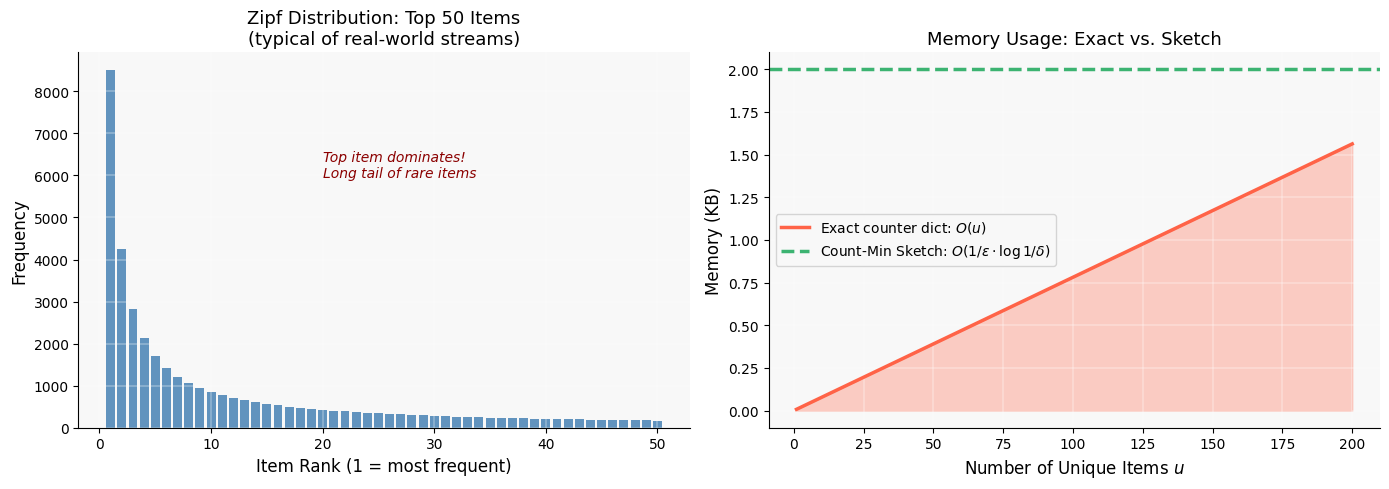

The sketch uses constant memory regardless of how many unique items exist!


In [2]:
# Visualize the streaming problem: Zipf distribution + memory comparison
n_unique = 200
ranks = np.arange(1, n_unique + 1)
probs = 1.0 / ranks
probs /= probs.sum()
true_counts = np.maximum((probs * 50000).astype(int), 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Zipf frequency distribution
ax = axes[0]
ax.bar(ranks[:50], true_counts[:50], color=BLUE, alpha=0.85)
ax.set_xlabel("Item Rank (1 = most frequent)", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.set_title("Zipf Distribution: Top 50 Items\n(typical of real-world streams)", fontsize=13)
ax.grid(alpha=0.3)
ax.text(20, true_counts[0]*0.7, "Top item dominates!\nLong tail of rare items",
        fontsize=10, color='darkred', style='italic')

# Right: memory needed
ax = axes[1]
u_vals = np.arange(1, n_unique + 1)
exact_mem_kb = u_vals * 8 / 1024   # 8 bytes per int64
sketch_mem = np.full_like(u_vals, 2.0, dtype=float)  # CMS ~2 KB, constant
ax.fill_between(u_vals, exact_mem_kb, alpha=0.3, color=RED)
ax.plot(u_vals, exact_mem_kb, color=RED, lw=2.5, label="Exact counter dict: $O(u)$")
ax.axhline(y=2.0, color=GREEN, lw=2.5, linestyle='--', label="Count-Min Sketch: $O(1/\\varepsilon \\cdot \\log 1/\\delta)$")
ax.set_xlabel("Number of Unique Items $u$", fontsize=12)
ax.set_ylabel("Memory (KB)", fontsize=12)
ax.set_title("Memory Usage: Exact vs. Sketch", fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print("The sketch uses constant memory regardless of how many unique items exist!")

---
## 2 · Sketch Algorithms: The General Paradigm

### What Makes an Algorithm a "Sketch"?

A **sketch** is a compact summary $S$ of a data stream such that you can answer queries approximately from $S$ alone. Formally, for a query $q$:

$$\Pr\left[|\hat{q}(S) - q(\sigma)| > \varepsilon \cdot \text{norm}\right] \leq \delta$$

where:
- $\varepsilon$ = **error tolerance** (how wrong we can be)
- $\delta$ = **failure probability** (the rare chance we exceed that error)
- $\text{norm}$ = a normalization factor (often $N$, the total stream length)

This is called an **$(\varepsilon, \delta)$-approximation**.

| Symbol | Meaning | Typical Value |
|--------|---------|---------------|
| $\varepsilon$ | Max relative error | 0.01 (1%) |
| $\delta$ | Failure probability | 0.01 (1%) |
| $N$ | Total stream items | $10^9$–$10^{12}$ |
| Memory | Sketch size | $O\!\left(\frac{1}{\varepsilon} \log \frac{1}{\delta}\right)$ |

### The Three Key Ideas

**1. Hashing** — compress a huge universe into a small array using a hash function:
$$h: \mathcal{U} \rightarrow [w], \quad h(x) = ((ax + b) \bmod p) \bmod w$$
where $p$ is a prime, $a, b$ are random. Any two distinct items $x \neq y$ collide with probability $\leq 1/w$.

> **Analogy:** A hash function is like a "random-looking filing cabinet" — every item always goes to the same drawer, but items are spread nearly uniformly across drawers.

**2. Randomization** — use multiple independent hash functions to reduce the probability that errors accumulate.

**3. Combining estimators** — take the min/median/mean of estimates from independent sub-structures to boost accuracy.

### The Sketch Zoo

| Sketch | Query | Core Trick |
|--------|-------|------------|
| **Bloom Filter** | Is $x$ in the set? | $k$ hash functions → $k$ bits; no false negatives |
| **HyperLogLog** | How many distinct items? | Leading zeros in hash → cardinality estimate |
| **Count-Min Sketch** | How often did $x$ appear? | 2D counter array; take minimum |
| **AMS / Count Sketch** | $\ell_2$ norm, heavy hitters | Sign-randomized counters; median trick |
| **Morris Counter** | Approximate total count | Probabilistic increment; $O(\log \log N)$ bits |

We focus on **Count-Min Sketch** — arguably the most widely deployed sketch in production systems (used in network monitoring, NLP, database systems, and streaming platforms).

---
## 3 · Count-Min Sketch: Structure and Intuition

### The Data Structure

Count-Min Sketch (Cormode & Muthukrishnan, 2005) answers:
> *"How many times has item $x$ appeared in the stream so far?"*

The structure is a **2D array of integer counters** with $d$ rows and $w$ columns:

$$C \in \mathbb{Z}^{d \times w}, \quad \text{initialized to all zeros}$$

Each row $i \in \{1, \ldots, d\}$ has its own independent hash function:
$$h_i : \mathcal{U} \rightarrow \{0, 1, \ldots, w-1\}$$

The parameters control the accuracy-memory trade-off:

| Parameter | Controls | Formula |
|-----------|----------|--------|
| $w$ (width / columns) | Accuracy — larger $w$ → less error | $w = \lceil e/\varepsilon \rceil$ |
| $d$ (depth / rows) | Confidence — larger $d$ → more reliable | $d = \lceil \ln(1/\delta) \rceil$ |
| Total memory | Cells × bits per cell | $w \times d$ counters |

### The Two Operations

**Update** (item $x$ arrives in the stream):
$$\text{For each row } i: \quad C[i,\, h_i(x)] \mathrel{+}= 1$$
We touch exactly $d$ cells — one per row. Cost: $O(d)$.

**Query** (estimate frequency of $x$):
$$\hat{f}_x = \min_{1 \leq i \leq d} C[i,\, h_i(x)]$$
We look up $d$ cells and return the minimum. Cost: $O(d)$.

### Why Take the Minimum?

Each cell $C[i, h_i(x)]$ accumulates:
$$C[i, h_i(x)] = f_x + \underbrace{\sum_{y \neq x,\; h_i(y)=h_i(x)} f_y}_{\text{collision noise from other items}}$$

The estimate is **always an overestimate**: $\hat{f}_x \geq f_x$ (no false negatives!). The collision noise is different in each row because each row uses a different hash function. The **minimum** over $d$ independent rows is the least-inflated estimate.

> **Analogy:** Imagine asking $d$ different witnesses "how many people were at the party?" Each witness tends to over-count (they include people from nearby parties due to confusion), but each over-counts *different* people. Taking the minimum of all witnesses gives the best estimate.

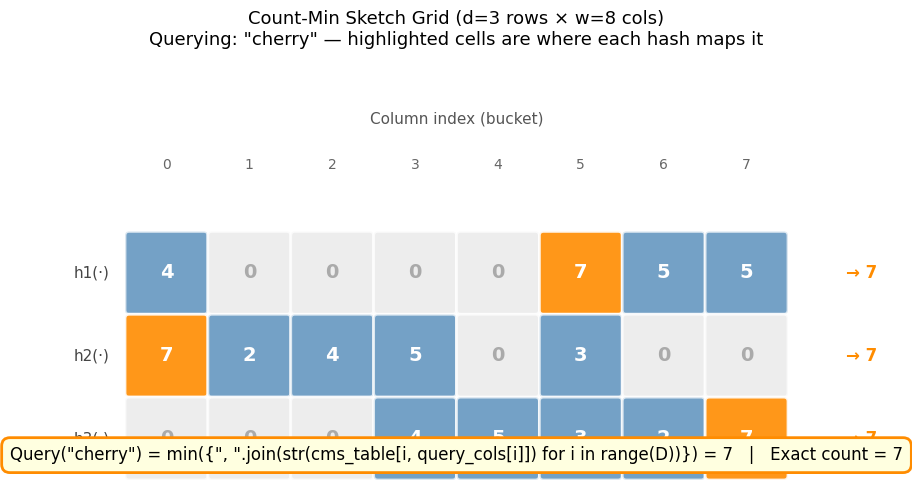

Inserted: apple×5, banana×3, cherry×7, date×2, elderberry×4
CMS estimate for "cherry": 7 (exact: 7)


In [3]:
# Visualize the CMS data structure: show what happens when we insert items
np.random.seed(7)

D, W = 3, 8
# Simulate hash functions
p = (1 << 31) - 1
rng = np.random.RandomState(42)
a_params = rng.randint(1, p, size=D)
b_params = rng.randint(0, p, size=D)

def make_hash(row, width):
    def h(item):
        x = hash(item) & 0x7FFFFFFF
        return int((a_params[row] * x + b_params[row]) % p % width)
    return h

hashes = [make_hash(i, W) for i in range(D)]

# Build a small CMS with a few items
cms_table = np.zeros((D, W), dtype=int)
items_to_insert = ['apple']*5 + ['banana']*3 + ['cherry']*7 + ['date']*2 + ['elderberry']*4
for item in items_to_insert:
    for i in range(D):
        cms_table[i, hashes[i](item)] += 1

query_item = 'cherry'
query_cols = [hashes[i](query_item) for i in range(D)]

fig, ax = plt.subplots(figsize=(13, 5))
ax.set_xlim(-0.5, W - 0.5)
ax.set_ylim(-0.5, D + 1.5)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title(f'Count-Min Sketch Grid (d={D} rows × w={W} cols)\nQuerying: "{query_item}" — highlighted cells are where each hash maps it',
             fontsize=13, pad=15)

for i in range(D):
    for j in range(W):
        is_query = (j == query_cols[i])
        color = ORANGE if is_query else (BLUE if cms_table[i, j] > 0 else '#e8e8e8')
        rect = patches.FancyBboxPatch((j - 0.45, D - 1 - i - 0.45), 0.9, 0.9,
                                       boxstyle="round,pad=0.05",
                                       facecolor=color, edgecolor='white', linewidth=2,
                                       alpha=0.9 if is_query else 0.75)
        ax.add_patch(rect)
        ax.text(j, D - 1 - i, str(cms_table[i, j]), ha='center', va='center',
                fontsize=14, fontweight='bold', color='white' if cms_table[i,j]>0 or is_query else '#aaa')

# Row labels
for i in range(D):
    ax.text(-0.9, D - 1 - i, f'h{i+1}(·)', ha='center', va='center',
            fontsize=11, color='#444')
    # Show the min
    val = cms_table[i, query_cols[i]]
    ax.text(W + 0.2, D - 1 - i, f'→ {val}', ha='left', va='center',
            fontsize=12, color=ORANGE, fontweight='bold')

# Column labels
for j in range(W):
    ax.text(j, D + 0.3, f'{j}', ha='center', va='center', fontsize=10, color='#666')
ax.text(W/2 - 0.5, D + 0.8, 'Column index (bucket)', ha='center', fontsize=11, color='#555')

# Estimate box
estimate = min(cms_table[i, query_cols[i]] for i in range(D))
exact_count = items_to_insert.count(query_item)
ax.text(W/2 - 0.5, -0.2,
        f'Query("{query_item}") = min({{", ".join(str(cms_table[i, query_cols[i]]) for i in range(D))}}) = {estimate}   |   Exact count = {exact_count}',
        ha='center', va='center', fontsize=12,
        bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', edgecolor=ORANGE, linewidth=2))

plt.tight_layout()
plt.show()
print(f'Inserted: apple×5, banana×3, cherry×7, date×2, elderberry×4')
print(f'CMS estimate for "cherry": {estimate} (exact: {exact_count})')

---
## 4 · Hash Functions: The Engine of CMS

### Universal Hashing

For CMS's guarantees to hold, the $d$ hash functions must be **pairwise independent**: knowing where $h_i$ maps one item tells you nothing about where it maps any other item.

We use the **universal hash family**:

$$h_i(x) = \left((a_i \cdot x + b_i) \bmod p\right) \bmod w$$

where $p$ is a prime larger than the universe size, and $a_i \in \{1, \ldots, p{-}1\}$, $b_i \in \{0, \ldots, p{-}1\}$ are drawn uniformly at random (different for each row).

### The Collision Bound

For any two **distinct** items $x \neq y$:

$$\Pr_{h_i}[h_i(x) = h_i(y)] \leq \frac{1}{w}$$

This is the key property: with $w$ columns, any two items hash to the same column with probability at most $1/w$. More columns → less collision → less noise in our estimates.

> **Analogy:** Imagine $w$ parking spaces and $n$ cars. If cars are assigned spaces randomly and independently, the probability that your car shares a space with any *specific* other car is $1/w$. Doubling the parking lot halves your expected number of conflicts.

### For String Items

When items are strings (not integers), we first map the string to an integer via its hash, then apply the universal hash:

$$x_{\text{int}} = \text{hash}(\text{string}) \bmod (2^{31})$$
$$h_i(\text{string}) = \left((a_i \cdot x_{\text{int}} + b_i) \bmod p\right) \bmod w$$

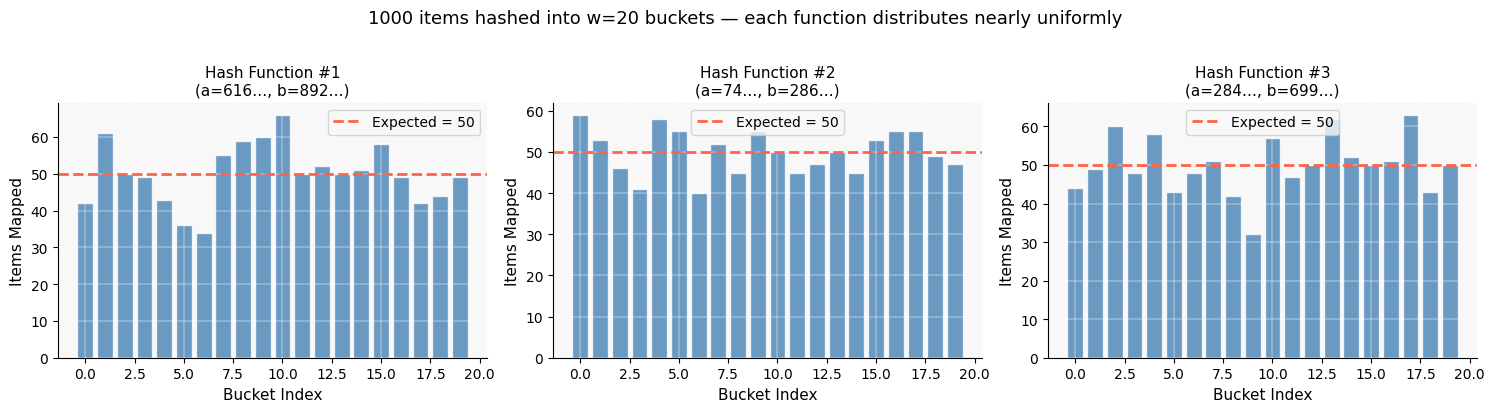

Three different hash functions all distribute items nearly uniformly — this is universal hashing.


In [4]:
# Demonstrate: universal hash functions spread items uniformly
p_demo = (1 << 31) - 1
W_demo = 20
N_items = 1000

# Generate random items
items = [f'item_{i}' for i in range(N_items)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for trial, ax in enumerate(axes):
    a = np.random.randint(1, p_demo)
    b = np.random.randint(0, p_demo)
    bucket_counts = np.zeros(W_demo, dtype=int)
    for item in items:
        x = hash(item) & 0x7FFFFFFF
        bucket = int((a * x + b) % p_demo % W_demo)
        bucket_counts[bucket] += 1

    ax.bar(range(W_demo), bucket_counts, color=BLUE, alpha=0.8, edgecolor='white')
    ax.axhline(N_items / W_demo, color=RED, lw=2, linestyle='--', label=f'Expected = {N_items/W_demo:.0f}')
    ax.set_xlabel('Bucket Index', fontsize=11)
    ax.set_ylabel('Items Mapped', fontsize=11)
    ax.set_title(f'Hash Function #{trial+1}\n(a={a % 1000}…, b={b % 1000}…)', fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

plt.suptitle(f'{N_items} items hashed into w={W_demo} buckets — each function distributes nearly uniformly',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()
print("Three different hash functions all distribute items nearly uniformly — this is universal hashing.")

---
## 5 · CMS from Scratch: Full Implementation

In [5]:
class CountMinSketch:
    """
    Count-Min Sketch for frequency estimation in data streams.
    
    Parameters
    ----------
    width : int
        Number of columns (w). Controls accuracy: error ≤ ε·N where ε = e/w.
        Set w = ceil(e / epsilon) for desired epsilon.
    depth : int
        Number of rows (d). Controls failure probability: δ = e^(-d).
        Set d = ceil(log(1/delta)) for desired delta.
    seed : int
        Random seed for hash function parameters.
    """
    def __init__(self, width: int, depth: int, seed: int = 42):
        self.width = width
        self.depth = depth
        self.table = np.zeros((depth, width), dtype=np.int64)
        self.total_count = 0

        # Mersenne prime — standard choice for universal hashing
        self.p = (1 << 31) - 1

        rng = np.random.RandomState(seed)
        self.a = rng.randint(1, self.p, size=depth)  # must be >= 1
        self.b = rng.randint(0, self.p, size=depth)

    def _hash(self, item: object, row: int) -> int:
        """Universal hash: h(x) = ((a*x + b) mod p) mod w"""
        x = hash(item) & 0x7FFFFFFF  # ensure positive
        return int((self.a[row] * x + self.b[row]) % self.p % self.width)

    def update(self, item: object, count: int = 1) -> None:
        """Record 'count' occurrences of item (O(d) time)."""
        self.total_count += count
        for row in range(self.depth):
            col = self._hash(item, row)
            self.table[row, col] += count

    def query(self, item: object) -> int:
        """Estimate frequency of item — always >= true frequency (O(d) time)."""
        return int(min(self.table[row, self._hash(item, row)] for row in range(self.depth)))

    def relative_error(self) -> float:
        """Theoretical error bound: ε = e / width"""
        return np.e / self.width

    def failure_prob(self) -> float:
        """Theoretical failure probability: δ = e^(-depth)"""
        return np.exp(-self.depth)

    def memory_bytes(self) -> int:
        """Bytes used by the counter table."""
        return self.table.nbytes

    def __repr__(self):
        return (f"CountMinSketch(w={self.width}, d={self.depth}, "
                f"ε≤{self.relative_error():.4f}, δ≤{self.failure_prob():.4f}, "
                f"memory={self.memory_bytes()} bytes)")


# Quick sanity check
cms_test = CountMinSketch(width=50, depth=5)
for word in ['cat', 'dog', 'cat', 'fish', 'cat', 'dog']:
    cms_test.update(word)

print(cms_test)
print()
for w in ['cat', 'dog', 'fish', 'unknown']:
    print(f"  query('{w}') = {cms_test.query(w)}  (exact: cat=3, dog=2, fish=1, unknown=0)")

CountMinSketch(w=50, d=5, ε≤0.0544, δ≤0.0067, memory=2000 bytes)

  query('cat') = 3  (exact: cat=3, dog=2, fish=1, unknown=0)
  query('dog') = 2  (exact: cat=3, dog=2, fish=1, unknown=0)
  query('fish') = 1  (exact: cat=3, dog=2, fish=1, unknown=0)
  query('unknown') = 0  (exact: cat=3, dog=2, fish=1, unknown=0)


---
## 6 · Mathematical Guarantees: Why CMS Works

### Setup and Goal

We want to show that with appropriate choices of $w$ and $d$, the CMS estimate $\hat{f}_x$ satisfies:

$$f_x \leq \hat{f}_x \leq f_x + \varepsilon N \quad \text{with probability at least } 1 - \delta$$

Notice the estimate is a **one-sided overestimate** — we never undercount.

---

### Step 1: Lower Bound (trivial)

Every time $x$ arrives, we increment $C[i, h_i(x)]$. So for every row $i$:
$$C[i, h_i(x)] \geq f_x \implies \hat{f}_x = \min_i C[i, h_i(x)] \geq f_x \quad \checkmark$$

---

### Step 2: Bounding the Noise in One Row

Fix any row $i$. The cell $C[i, h_i(x)]$ stores:
$$C[i, h_i(x)] = f_x + \underbrace{\sum_{y \neq x} f_y \cdot \mathbf{1}[h_i(y) = h_i(x)]}_{\text{collision noise} \; Z_i}$$

We want to bound $Z_i$. Define indicator variables: for each $y \neq x$, let
$$X_{y,i} = \mathbf{1}[h_i(y) = h_i(x)]$$

By the **universal hashing** property: $\mathbb{E}[X_{y,i}] = \Pr[h_i(y) = h_i(x)] \leq \dfrac{1}{w}$

By **linearity of expectation**:
$$\mathbb{E}[Z_i] = \sum_{y \neq x} f_y \cdot \mathbb{E}[X_{y,i}] \leq \frac{1}{w} \sum_{y \neq x} f_y \leq \frac{N}{w}$$

> **Intuition:** The expected noise in any single row is at most $N/w$. Think of it as: each of the $N$ stream items has a $1/w$ probability of landing in the same bucket as $x$.

---

### Step 3: Markov's Inequality on One Row

For any non-negative random variable $Z$ with mean $\mu$, **Markov's inequality** says:
$$\Pr[Z \geq t] \leq \frac{\mu}{t}$$

> **Intuition:** If the average is $\mu$, the variable can only be $\geq t$ a fraction $\mu/t$ of the time. A random variable can't be large "too often" if its average is small.

Applying this to $Z_i$ with $t = \varepsilon N$:
$$\Pr[Z_i \geq \varepsilon N] \leq \frac{N/w}{\varepsilon N} = \frac{1}{w\varepsilon}$$

Setting $w = \lceil e/\varepsilon \rceil$ gives $1/(w\varepsilon) \leq 1/e \approx 0.368$.
So each row has at most a $1/e$ chance of having noise $\geq \varepsilon N$.

---

### Step 4: Boost with Multiple Rows

The $d$ rows use **independent** hash functions, so their noises $Z_1, Z_2, \ldots, Z_d$ are independent.

The query only overestimates by more than $\varepsilon N$ if **all $d$ rows** have noise $\geq \varepsilon N$:
$$\Pr[\hat{f}_x > f_x + \varepsilon N] = \Pr\left[\bigcap_{i=1}^d \{Z_i \geq \varepsilon N\}\right] = \prod_{i=1}^d \Pr[Z_i \geq \varepsilon N] \leq \left(\frac{1}{e}\right)^d$$

Setting $d = \lceil \ln(1/\delta) \rceil$ gives $(1/e)^d \leq \delta$.

---

### The Final Guarantee

$$\boxed{f_x \leq \hat{f}_x \leq f_x + \varepsilon N \quad \text{with probability } \geq 1 - \delta}$$

using $w = \lceil e/\varepsilon \rceil$ columns and $d = \lceil \ln(1/\delta) \rceil$ rows.

**Memory:** $w \times d = O\!\left(\dfrac{1}{\varepsilon} \log \dfrac{1}{\delta}\right)$ counters — independent of the universe size $u$ and the stream length $N$!

| Desired accuracy | Required width $w$ | Required depth $d$ |
|-----------------|-------------------|--------------------|
| $\varepsilon=0.01$, $\delta=0.01$ | $\lceil e/0.01 \rceil = 272$ | $\lceil \ln 100 \rceil = 5$ |
| $\varepsilon=0.001$, $\delta=0.001$ | 2719 | 7 |
| $\varepsilon=0.1$, $\delta=0.1$ | 28 | 3 |

In [6]:
# Generate a realistic Zipf-distributed word stream
VOCAB_SIZE = 500       # unique words
STREAM_SIZE = 100_000  # total events

vocab = [f"word_{i:03d}" for i in range(VOCAB_SIZE)]

# Zipf law: word rank k has probability ∝ 1/k
ranks = np.arange(1, VOCAB_SIZE + 1, dtype=float)
probs = 1.0 / ranks
probs /= probs.sum()

stream = np.random.choice(vocab, size=STREAM_SIZE, p=probs)

print(f"Stream generated: {STREAM_SIZE:,} items, {VOCAB_SIZE} unique words")
print(f"Most frequent: {stream[:5]}...")

# Check distribution
true_counts = Counter(stream)
top10 = true_counts.most_common(10)
print(f"\nTop 10 words:")
for word, cnt in top10:
    bar = '█' * (cnt // 500)
    print(f"  {word}: {cnt:5d}  {bar}")

Stream generated: 100,000 items, 500 unique words
Most frequent: ['word_075' 'word_430' 'word_021' 'word_016' 'word_000']...

Top 10 words:
  word_000: 14701  █████████████████████████████
  word_001:  7546  ███████████████
  word_002:  4844  █████████
  word_003:  3706  ███████
  word_004:  2991  █████
  word_005:  2438  ████
  word_006:  2138  ████
  word_007:  1853  ███
  word_008:  1626  ███
  word_009:  1463  ██


In [7]:
# Build exact Counter baseline and CMS, then compare
EPSILON = 0.01  # 1% error tolerance
DELTA   = 0.01  # 1% failure probability

# Optimal CMS dimensions from the theory
width_opt = int(np.ceil(np.e / EPSILON))   # w = ceil(e / ε)
depth_opt = int(np.ceil(np.log(1 / DELTA))) # d = ceil(ln(1/δ))

print(f"Parameters: ε={EPSILON}, δ={DELTA}")
print(f"  Optimal width  w = ceil(e/{EPSILON}) = {width_opt}")
print(f"  Optimal depth  d = ceil(ln(1/{DELTA})) = {depth_opt}")
print()

# Build the sketch
cms = CountMinSketch(width=width_opt, depth=depth_opt)
for item in stream:
    cms.update(item)

print(cms)
print()
print(f"Exact dict memory:  {VOCAB_SIZE * 50:,} bytes (approx, key+value)")
print(f"CMS table memory:   {cms.memory_bytes():,} bytes")
print(f"Memory reduction:   {VOCAB_SIZE * 50 / cms.memory_bytes():.1f}x")
print()
print(f"Theoretical error bound: ε·N = {EPSILON:.3f} × {STREAM_SIZE:,} = {EPSILON*STREAM_SIZE:.0f} counts")

# Query all words
cms_estimates = {word: cms.query(word) for word in vocab}
errors = {word: cms_estimates[word] - true_counts.get(word, 0) for word in vocab}

Parameters: ε=0.01, δ=0.01
  Optimal width  w = ceil(e/0.01) = 272
  Optimal depth  d = ceil(ln(1/0.01)) = 5

CountMinSketch(w=272, d=5, ε≤0.0100, δ≤0.0067, memory=10880 bytes)

Exact dict memory:  25,000 bytes (approx, key+value)
CMS table memory:   10,880 bytes
Memory reduction:   2.3x

Theoretical error bound: ε·N = 0.010 × 100,000 = 1000 counts


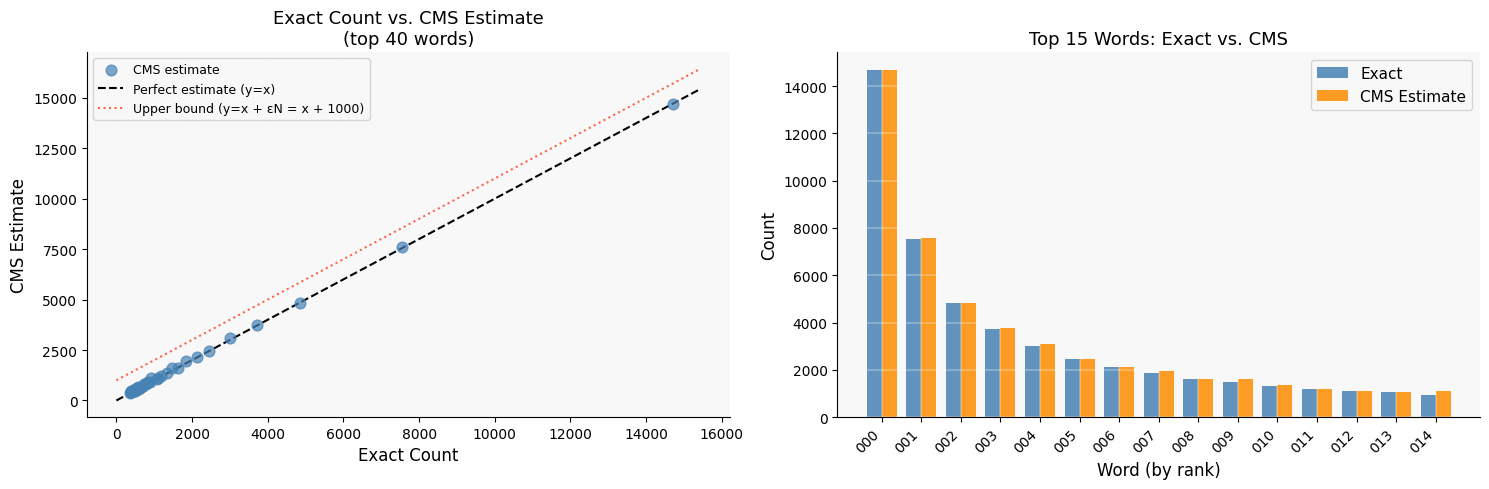

Max observed error: 325  |  Theoretical bound: 1000
Bound violated: 0/500 words (0.00%)  (allowed: 1%)
All CMS estimates are >= exact count (no undercounting): True


In [8]:
# Plot 1: Exact vs CMS counts for top words
top_n = 40
top_words = [w for w, _ in true_counts.most_common(top_n)]
exact_vals = [true_counts[w] for w in top_words]
cms_vals   = [cms_estimates[w] for w in top_words]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scatter: exact vs estimate
ax = axes[0]
ax.scatter(exact_vals, cms_vals, color=BLUE, alpha=0.7, s=60, zorder=3, label='CMS estimate')
max_val = max(max(exact_vals), max(cms_vals)) * 1.05
ax.plot([0, max_val], [0, max_val], color='black', lw=1.5, linestyle='--', label='Perfect estimate (y=x)')
error_bound = EPSILON * STREAM_SIZE
ax.plot([0, max_val], [error_bound, max_val + error_bound], color=RED, lw=1.5,
        linestyle=':', label=f'Upper bound (y=x + εN = x + {error_bound:.0f})')
ax.set_xlabel('Exact Count', fontsize=12)
ax.set_ylabel('CMS Estimate', fontsize=12)
ax.set_title('Exact Count vs. CMS Estimate\n(top 40 words)', fontsize=13)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Bar: side-by-side for top 15
ax = axes[1]
n_show = 15
x = np.arange(n_show)
w = 0.38
ax.bar(x - w/2, exact_vals[:n_show], w, color=BLUE, alpha=0.85, label='Exact')
ax.bar(x + w/2, cms_vals[:n_show],   w, color=ORANGE, alpha=0.85, label='CMS Estimate')
ax.set_xticks(x)
ax.set_xticklabels([w.replace('word_', '') for w in top_words[:n_show]], rotation=45, ha='right')
ax.set_xlabel('Word (by rank)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Top 15 Words: Exact vs. CMS', fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Report accuracy
all_errors = list(errors.values())
max_err = max(all_errors)
violations = sum(1 for e in all_errors if e > error_bound)
print(f"Max observed error: {max_err:,}  |  Theoretical bound: {error_bound:.0f}")
print(f"Bound violated: {violations}/{VOCAB_SIZE} words ({100*violations/VOCAB_SIZE:.2f}%)  "
      f"(allowed: {100*DELTA:.0f}%)")
print(f"All CMS estimates are >= exact count (no undercounting): {all(e >= 0 for e in all_errors)}")

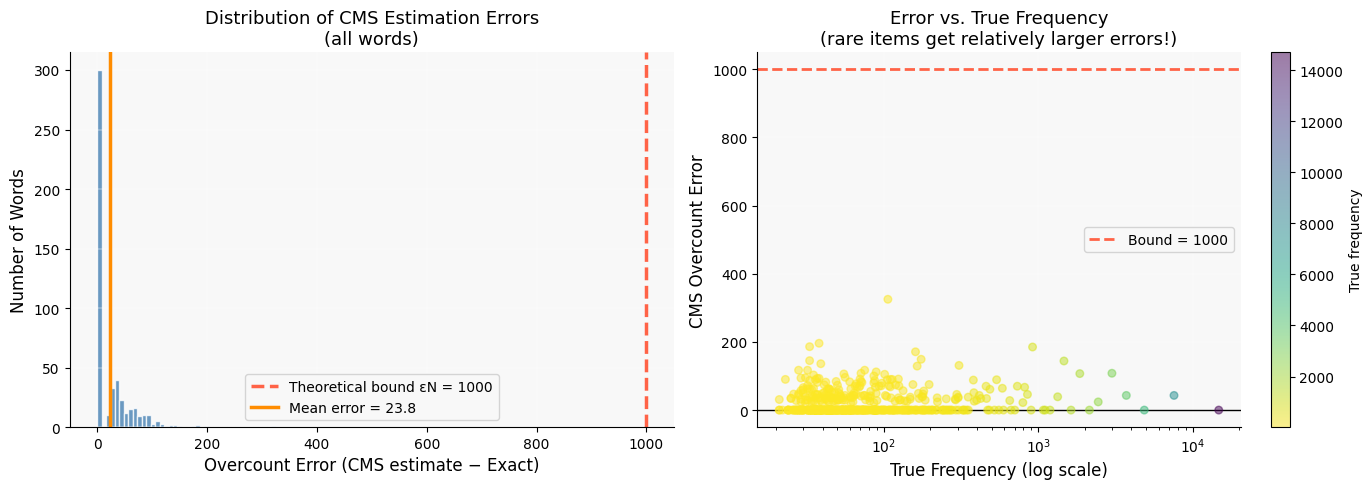

Key observation: errors are concentrated in low-frequency items.
For frequent items (the 'heavy hitters'), CMS is extremely accurate.


In [9]:
# Plot 2: Error distribution and analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of absolute errors
ax = axes[0]
ax.hist(all_errors, bins=40, color=BLUE, alpha=0.8, edgecolor='white')
ax.axvline(error_bound, color=RED, lw=2.5, linestyle='--',
           label=f'Theoretical bound εN = {error_bound:.0f}')
ax.axvline(np.mean(all_errors), color=ORANGE, lw=2.5, linestyle='-',
           label=f'Mean error = {np.mean(all_errors):.1f}')
ax.set_xlabel('Overcount Error (CMS estimate − Exact)', fontsize=12)
ax.set_ylabel('Number of Words', fontsize=12)
ax.set_title('Distribution of CMS Estimation Errors\n(all words)', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Error vs. true frequency (log scale)
ax = axes[1]
exact_arr = np.array([true_counts.get(w, 0) for w in vocab])
error_arr = np.array([errors[w] for w in vocab])
scatter = ax.scatter(exact_arr, error_arr, alpha=0.5, s=30,
                     c=exact_arr, cmap='viridis_r', zorder=3)
ax.axhline(error_bound, color=RED, lw=2, linestyle='--', label=f'Bound = {error_bound:.0f}')
ax.axhline(0, color='black', lw=1)
ax.set_xscale('log')
ax.set_xlabel('True Frequency (log scale)', fontsize=12)
ax.set_ylabel('CMS Overcount Error', fontsize=12)
ax.set_title('Error vs. True Frequency\n(rare items get relatively larger errors!)', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.colorbar(scatter, ax=ax, label='True frequency')

plt.tight_layout()
plt.show()

print("Key observation: errors are concentrated in low-frequency items.")
print("For frequent items (the 'heavy hitters'), CMS is extremely accurate.")

---
## 7 · Effect of Width and Depth on Accuracy

The theory tells us:

$$\text{Error} \leq \varepsilon N = \frac{e}{w} \cdot N \quad \text{with probability} \geq 1 - e^{-d}$$

So:
- **Doubling the width $w$** → halves the maximum error (linear trade-off)
- **Adding one more row (depth $d$)** → reduces failure probability *exponentially*

This means:
- Width is the "expensive" dial — you need to multiply $w$ by 10 to get 10× better accuracy
- Depth is the "cheap" dial — adding just a few rows gives you astronomically high confidence

> **Key insight:** In practice, $d = 5$ rows gives failure probability $e^{-5} \approx 0.007$ (less than 1%), and $d = 10$ gives $e^{-10} \approx 0.00005$. You almost never need more than 7-10 rows.

Running parameter sweep...


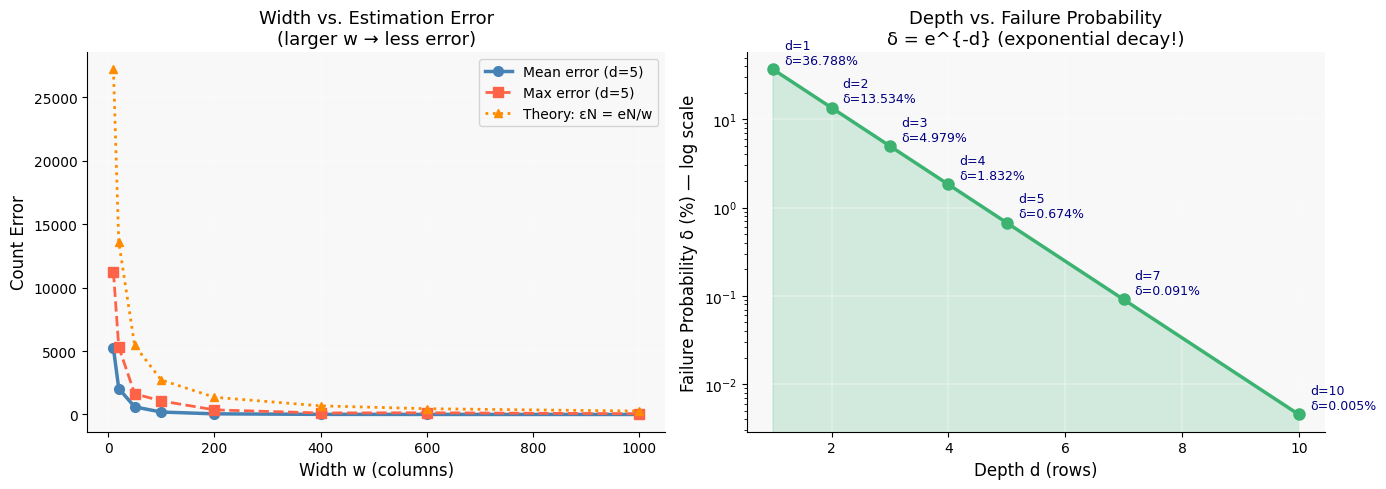

Depth is the 'cheap' dial — adding 1 row exponentially reduces failure probability.
Width is the 'expensive' dial — you need 10x width to get 10x better accuracy.


In [10]:
# Parameter sweep: how width and depth affect accuracy
widths = [10, 20, 50, 100, 200, 400, 600, 1000]
depths = [1, 2, 3, 4, 5, 7, 10]

# Measure mean absolute error across all vocab words
def mean_abs_error(width, depth, stream, vocab, true_counts):
    cms_tmp = CountMinSketch(width=width, depth=depth)
    for item in stream:
        cms_tmp.update(item)
    errors = [cms_tmp.query(w) - true_counts.get(w, 0) for w in vocab]
    return np.mean(errors), np.max(errors)

print("Running parameter sweep...")
mean_errors_by_width  = []
max_errors_by_width   = []
for w in widths:
    me, mxe = mean_abs_error(w, 5, stream, vocab, true_counts)
    mean_errors_by_width.append(me)
    max_errors_by_width.append(mxe)

failure_prob_by_depth = [np.exp(-d) * 100 for d in depths]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Width vs error
ax = axes[0]
ax.plot(widths, mean_errors_by_width, 'o-', color=BLUE, lw=2.5, ms=7, label='Mean error (d=5)')
ax.plot(widths, max_errors_by_width, 's--', color=RED, lw=2, ms=7, label='Max error (d=5)')
theoretical = [np.e / w * STREAM_SIZE for w in widths]
ax.plot(widths, theoretical, '^:', color=ORANGE, lw=2, ms=6, label='Theory: εN = eN/w')
ax.set_xlabel('Width w (columns)', fontsize=12)
ax.set_ylabel('Count Error', fontsize=12)
ax.set_title('Width vs. Estimation Error\n(larger w → less error)', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Depth vs failure probability
ax = axes[1]
ax.semilogy(depths, failure_prob_by_depth, 'o-', color=GREEN, lw=2.5, ms=8)
ax.fill_between(depths, failure_prob_by_depth, alpha=0.2, color=GREEN)
ax.set_xlabel('Depth d (rows)', fontsize=12)
ax.set_ylabel('Failure Probability δ (%) — log scale', fontsize=12)
ax.set_title('Depth vs. Failure Probability\nδ = e^{-d} (exponential decay!)', fontsize=13)
ax.grid(alpha=0.3)
for d, fp in zip(depths, failure_prob_by_depth):
    ax.annotate(f'd={d}\nδ={fp:.3f}%', (d, fp), textcoords='offset points',
                xytext=(8, 4), fontsize=9, color=NAVY)

plt.tight_layout()
plt.show()
print("Depth is the 'cheap' dial — adding 1 row exponentially reduces failure probability.")
print("Width is the 'expensive' dial — you need 10x width to get 10x better accuracy.")

In [ ]:
# Interactive widget: tune w and d, see accuracy and memory live
def explore_cms(width=272, depth=5, query_word='word_000'):
    cms_exp = CountMinSketch(width=width, depth=depth)
    for item in stream:
        cms_exp.update(item)

    exact = true_counts.get(query_word, 0)
    estimate = cms_exp.query(query_word)
    err_pct = (estimate - exact) / max(exact, 1) * 100
    bound = np.e / width * STREAM_SIZE

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Left: CMS table as heatmap (first 5 cols for brevity)
    ax = axes[0]
    show_w = min(width, 30)
    im = ax.imshow(cms_exp.table[:, :show_w], cmap='YlOrRd', aspect='auto')
    ax.set_xlabel(f'Column (showing first {show_w} of {width})', fontsize=11)
    ax.set_ylabel('Row (hash function)', fontsize=11)
    ax.set_title(f'CMS Table (w={width}, d={depth})\n'
                 f'Memory: {cms_exp.memory_bytes():,} bytes', fontsize=12)
    plt.colorbar(im, ax=ax, label='Counter value')

    # Right: query result with error bound
    ax = axes[1]
    ax.axis('off')
    info = (
        f"Query: '{query_word}'\n\n"
        f"Exact count:       {exact:>8,}\n"
        f"CMS estimate:      {estimate:>8,}\n"
        f"Error:             {estimate - exact:>8,} ({err_pct:+.1f}%)\n\n"
        f"Theoretical bound: εN = {bound:>8.0f}\n"
        f"Within bound?      {'YES ✓' if estimate - exact <= bound else 'NO ✗'}\n\n"
        f"ε = e/w = {np.e:.3f}/{width} = {np.e/width:.5f}\n"
        f"δ = e^(-d) = e^(-{depth}) = {np.exp(-depth):.5f}"
    )
    ax.text(0.1, 0.5, info, transform=ax.transAxes, fontsize=12,
            verticalalignment='center', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='#f0f8ff', edgecolor=BLUE, linewidth=2))

    plt.tight_layout()
    plt.show()

# Word list for widget dropdown
top_20_words = [w for w, _ in true_counts.most_common(20)]
rare_words   = [w for w, c in true_counts.most_common()[-10:]]

widgets.interact(
    explore_cms,
    width=widgets.IntSlider(min=10, max=800, step=10, value=272,
                            description='Width w:', style={'description_width': '80px'}),
    depth=widgets.IntSlider(min=1, max=10, step=1, value=5,
                            description='Depth d:', style={'description_width': '80px'}),
    query_word=widgets.Dropdown(options=top_20_words + rare_words,
                                value=top_20_words[0], description='Query:',
                                style={'description_width': '80px'})
);

interactive(children=(IntSlider(value=272, description='Width w:', max=800, min=10, step=10, style=SliderStyle…

---
## 8 · Summary

### What We Covered

| Concept | Key Idea |
|---------|----------|
| **Data Streaming Problem** | Items arrive one at a time; memory ≪ stream size; need approximate answers |
| **Sketch Algorithm** | Compact summary + hash functions → $(\varepsilon, \delta)$-approximate query answers |
| **Accuracy-Memory Bargain** | Accept bounded error → memory independent of universe size $u$ |
| **Count-Min Sketch** | $d \times w$ counter array; $d$ independent hash functions; update = increment $d$ cells; query = min of $d$ cells |
| **Universal Hashing** | $h(x) = ((ax+b) \bmod p) \bmod w$; collision probability $\leq 1/w$ |
| **Error Guarantee** | $f_x \leq \hat{f}_x \leq f_x + \varepsilon N$ with probability $\geq 1 - \delta$ |
| **Width $w$** | Controls accuracy: $\varepsilon = e/w$ → larger $w$ → smaller error |
| **Depth $d$** | Controls confidence: $\delta = e^{-d}$ → each extra row exponentially reduces failure prob |
| **Markov's Inequality** | The key tool in the proof: $\Pr[Z \geq t] \leq \mathbb{E}[Z]/t$ |
| **No Undercounting** | CMS is always a one-sided overestimate: $\hat{f}_x \geq f_x$ always |
| **Memory** | $O\!\left(\frac{1}{\varepsilon} \log \frac{1}{\delta}\right)$ counters — independent of $u$ and $N$ |
| **Real-World Use** | Network monitoring, NLP (top-k words), database query optimization, streaming analytics |

### Design Recipe

Given desired $\varepsilon$ (error tolerance) and $\delta$ (failure probability):

$$w = \left\lceil \frac{e}{\varepsilon} \right\rceil, \quad d = \left\lceil \ln \frac{1}{\delta} \right\rceil$$

Then $\hat{f}_x \leq f_x + \varepsilon N$ with probability $\geq 1 - \delta$.

### Going Further

- **Heavy Hitters**: Use CMS to find all items with $f_x > \phi N$ (the "elephant flows" in network traffic)
- **Count Sketch**: Uses ±1 randomization instead of minimum — unbiased estimator, better for $L_2$ queries
- **Deletions**: CMS supports decrements! Set `update(item, count=-1)` — counters stay non-negative if deletion ≤ insertion
- **Mergeable**: Two CMS sketches on different shards can be merged by element-wise addition — great for distributed systems